In [52]:
import akshare as ak
# stock_zh_index_spot_df = ak.stock_zh_index_spot()
import pandas as pd
# pd.options.plotting.backend = "plotly"


In [17]:
df = ak.stock_lhb_detail_em(start_date="20230323", end_date="20230323")


In [24]:
df[['代码','名称','涨跌幅','上榜原因','解读']].sort_values('涨跌幅')

,代码,名称,涨跌幅,上榜原因,解读
26,600225,卓朗科技,-10.0149,有价格涨跌幅限制的日收盘价格跌幅偏离值达到7%的前五只证券,普通席位卖出，成功率24.57%
25,600070,浙江富润,-10.0147,有价格涨跌幅限制的日收盘价格跌幅偏离值达到7%的前五只证券,普通席位卖出，成功率56.33%
41,603888,新华网,-9.9886,有价格涨跌幅限制的日收盘价格跌幅偏离值达到7%的前五只证券,1家机构卖出，成功率33.94%
30,600818,中路股份,-9.8383,有价格涨跌幅限制的日收盘价格跌幅偏离值达到7%的前五只证券,上海资金卖出，成功率46.50%
29,600738,丽尚国潮,-9.2757,有价格涨跌幅限制的日收盘价格跌幅偏离值达到7%的前五只证券,1家机构卖出，成功率33.79%
40,603860,中公高科,-8.3425,非ST、*ST和S证券连续三个交易日内收盘价格跌幅偏离值累计达到20%的证券,实力游资卖出，成功率19.83%
21,301001,凯淳股份,-8.2915,日换手率达到30%的前5只证券,2家机构卖出，成功率24.84%
38,603282,亚光股份,-7.7099,有价格涨跌幅限制的日换手率达到20%的前五只证券,浙江资金卖出，成功率46.96%
24,301365,矩阵股份,-7.4786,日换手率达到30%的前5只证券,3家机构卖出，成功率30.66%
7,002280,联络互动,-7.0455,日跌幅偏离值达到7%的前5只证券,上海资金卖出，成功率34.89%


In [18]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np



font_color=df.apply(lambda s: np.where(s.name == "col1", "black",
                                       np.where(s.str.contains("-"), "green", "red"),)).T.values

table_trace = go.Table(
                 header = dict(height = 50,
                               values = [f"<b>{c.title()}</b>" for c in df.columns],
                               align = ['left']*3,
                               fill_color = '#386dea',
                               font_color = '#fcfcfc',
                               font_size =14),
                 cells = dict(values = df.T.values,
                              line = dict(color='#506784'),
                              align = ['left']*3,
                              font_color=font_color,
                              font_family="Arial", 
                              font_size=14,   
                              height = 30,
                              fill = dict(color='rgb(245,245,245)'))
                             )
                 

layout = go.Layout(width=400, height=415, autosize=False, 
              title_text='Table title',
                   title_x=0.5, showlegend=False)
fig = go.Figure(data=[table_trace], layout=layout)
fig

AttributeError: Can only use .str accessor with string values!

In [222]:
indices = {
    'sh000001':'上证指数',
    'sz399001':'深证成指',
    'sh000300':'沪深300',
    'sh000688':'科创50',
    'sh000016':'上证50',
    'sh000852':'中证1000'
}

In [233]:
indices

dict

In [228]:
for index in indices:
    index_daily = ak.stock_zh_index_daily_em(symbol=index)
    index_daily.to_parquet('sh000001.parquet', index = False)

上证指数
深证成指
沪深300
科创50
上证50
中证1000


In [33]:
import pandas as pd
pd.set_option('display.max_rows', None)

stock_zh_index_spot_df

NameError: name 'stock_zh_index_spot_df' is not defined

In [25]:
indices = ['sh000001','sz399001','sh000300','sh000688','sh000016','sh000852']


sh300 = ak.stock_zh_index_daily_em(symbol="sh000001")


In [26]:
sh300

,date,open,close,high,low,volume,amount
0,1990-12-19,96.05,99.98,99.98,95.79,1260,4.940000e+05
1,1990-12-20,104.30,104.39,104.39,99.98,197,8.400000e+04
2,1990-12-21,109.07,109.13,109.13,103.73,28,1.600000e+04
3,1990-12-24,113.57,114.55,114.55,109.13,32,3.100000e+04
4,1990-12-25,120.09,120.25,120.25,114.55,15,6.000000e+03
...,...,...,...,...,...,...,...
7876,2023-03-17,3245.26,3250.55,3279.92,3240.16,343001022,4.319831e+11
7877,2023-03-20,3253.93,3234.91,3267.99,3231.65,392517391,4.802924e+11
7878,2023-03-21,3240.84,3255.65,3256.00,3237.89,301810779,3.880471e+11
7879,2023-03-22,3263.41,3265.75,3279.39,3255.74,290840462,3.825091e+11


In [220]:
# sh300.to_parquet('sh000001.parquet', index = False)
sh300.to_csv('sh000001.csv', index = False)

In [23]:
import tushare as ts
pro = ts.pro_api('158ce95d6e799f55b8e8277aa1f6138fa71acf9c52df5ec667296fbc')

df = pro.daily(ts_code="600001.SH", period="daily", start_date="19910101", end_date='20230321', adjust="")

In [5]:
import os
import pandas as pd
home_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

code = '600089'
df = pd .read_parquet(home_path + '/market_data/stock/daily/' + code + '.parquet')

In [6]:
df

,日期,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,1997-06-18,11.50,12.60,12.77,10.39,223593,2.475220e+08,45.86,142.77,7.41,74.53
1,1997-06-19,11.97,11.34,12.35,11.34,92838,1.089010e+08,8.02,-10.00,-1.26,30.95
2,1997-06-20,10.69,11.47,11.80,10.50,80570,9.041500e+07,11.46,1.15,0.13,26.86
3,1997-06-23,11.60,10.89,11.67,10.71,56794,6.355500e+07,8.37,-5.06,-0.58,18.93
4,1997-06-24,11.00,11.44,11.98,10.89,50377,5.844100e+07,10.01,5.05,0.55,16.79
...,...,...,...,...,...,...,...,...,...,...,...
6053,2023-03-16,22.20,21.87,22.36,21.76,848100,1.869514e+09,2.67,-2.71,-0.61,2.18
6054,2023-03-17,22.04,21.88,22.09,21.39,841844,1.830331e+09,3.20,0.05,0.01,2.17
6055,2023-03-20,21.84,21.69,21.98,21.52,533246,1.160561e+09,2.10,-0.87,-0.19,1.37
6056,2023-03-21,21.80,21.85,21.88,21.57,378617,8.216361e+08,1.43,0.74,0.16,0.97


In [5]:
stock_list = pro.stock_basic(exchange='', list_status='L', fields='ts_code,symbol,name,list_date')

In [11]:
for row, stock in stock_list.iterrows():
    print(stock['ts_code'])

000001.SZ
000002.SZ
000004.SZ
000005.SZ
000006.SZ
000007.SZ
000008.SZ
000009.SZ
000010.SZ
000011.SZ
000012.SZ
000014.SZ
000016.SZ
000017.SZ
000019.SZ
000020.SZ
000021.SZ
000023.SZ
000025.SZ
000026.SZ
000027.SZ
000028.SZ
000029.SZ
000030.SZ
000031.SZ
000032.SZ
000034.SZ
000035.SZ
000036.SZ
000037.SZ
000038.SZ
000039.SZ
000040.SZ
000042.SZ
000045.SZ
000046.SZ
000048.SZ
000049.SZ
000050.SZ
000055.SZ
000056.SZ
000058.SZ
000059.SZ
000060.SZ
000061.SZ
000062.SZ
000063.SZ
000065.SZ
000066.SZ
000068.SZ
000069.SZ
000070.SZ
000078.SZ
000088.SZ
000089.SZ
000090.SZ
000096.SZ
000099.SZ
000100.SZ
000150.SZ
000151.SZ
000153.SZ
000155.SZ
000156.SZ
000157.SZ
000158.SZ
000159.SZ
000166.SZ
000301.SZ
000333.SZ
000338.SZ
000400.SZ
000401.SZ
000402.SZ
000403.SZ
000404.SZ
000407.SZ
000408.SZ
000409.SZ
000410.SZ
000411.SZ
000413.SZ
000415.SZ
000416.SZ
000417.SZ
000419.SZ
000420.SZ
000421.SZ
000422.SZ
000423.SZ
000425.SZ
000426.SZ
000428.SZ
000429.SZ
000430.SZ
000488.SZ
000498.SZ
000501.SZ
000503.SZ
000504.SZ


300205.SZ
300206.SZ
300207.SZ
300208.SZ
300209.SZ
300210.SZ
300211.SZ
300212.SZ
300213.SZ
300214.SZ
300215.SZ
300217.SZ
300218.SZ
300219.SZ
300220.SZ
300221.SZ
300222.SZ
300223.SZ
300224.SZ
300225.SZ
300226.SZ
300227.SZ
300228.SZ
300229.SZ
300230.SZ
300231.SZ
300232.SZ
300233.SZ
300234.SZ
300235.SZ
300236.SZ
300237.SZ
300238.SZ
300239.SZ
300240.SZ
300241.SZ
300242.SZ
300243.SZ
300244.SZ
300245.SZ
300246.SZ
300247.SZ
300248.SZ
300249.SZ
300250.SZ
300251.SZ
300252.SZ
300253.SZ
300254.SZ
300255.SZ
300256.SZ
300257.SZ
300258.SZ
300259.SZ
300260.SZ
300261.SZ
300262.SZ
300263.SZ
300264.SZ
300265.SZ
300266.SZ
300267.SZ
300268.SZ
300269.SZ
300270.SZ
300271.SZ
300272.SZ
300273.SZ
300274.SZ
300275.SZ
300276.SZ
300277.SZ
300278.SZ
300279.SZ
300280.SZ
300281.SZ
300282.SZ
300283.SZ
300284.SZ
300285.SZ
300286.SZ
300287.SZ
300288.SZ
300289.SZ
300290.SZ
300291.SZ
300292.SZ
300293.SZ
300294.SZ
300295.SZ
300296.SZ
300297.SZ
300298.SZ
300299.SZ
300300.SZ
300301.SZ
300302.SZ
300303.SZ
300304.SZ
300305.SZ


600604.SH
600605.SH
600606.SH
600608.SH
600609.SH
600610.SH
600611.SH
600612.SH
600613.SH
600615.SH
600616.SH
600617.SH
600618.SH
600619.SH
600620.SH
600621.SH
600622.SH
600623.SH
600624.SH
600626.SH
600628.SH
600629.SH
600630.SH
600633.SH
600635.SH
600636.SH
600637.SH
600638.SH
600639.SH
600640.SH
600641.SH
600642.SH
600643.SH
600644.SH
600645.SH
600647.SH
600648.SH
600649.SH
600650.SH
600651.SH
600653.SH
600654.SH
600655.SH
600657.SH
600658.SH
600660.SH
600661.SH
600662.SH
600663.SH
600664.SH
600665.SH
600666.SH
600667.SH
600668.SH
600671.SH
600673.SH
600674.SH
600675.SH
600676.SH
600678.SH
600679.SH
600681.SH
600682.SH
600683.SH
600684.SH
600685.SH
600686.SH
600688.SH
600689.SH
600690.SH
600691.SH
600692.SH
600693.SH
600694.SH
600696.SH
600697.SH
600698.SH
600699.SH
600702.SH
600703.SH
600704.SH
600705.SH
600706.SH
600707.SH
600708.SH
600710.SH
600711.SH
600712.SH
600713.SH
600714.SH
600715.SH
600716.SH
600717.SH
600718.SH
600719.SH
600720.SH
600721.SH
600722.SH
600724.SH
600725.SH


605266.SH
605268.SH
605277.SH
605286.SH
605287.SH
605288.SH
605289.SH
605296.SH
605298.SH
605299.SH
605300.SH
605303.SH
605305.SH
605318.SH
605319.SH
605333.SH
605336.SH
605337.SH
605338.SH
605339.SH
605358.SH
605365.SH
605366.SH
605368.SH
605369.SH
605376.SH
605377.SH
605378.SH
605388.SH
605389.SH
605398.SH
605399.SH
605488.SH
605499.SH
605500.SH
605507.SH
605555.SH
605566.SH
605567.SH
605577.SH
605580.SH
605588.SH
605589.SH
605598.SH
605599.SH
688001.SH
688002.SH
688003.SH
688004.SH
688005.SH
688006.SH
688007.SH
688008.SH
688009.SH
688010.SH
688011.SH
688012.SH
688013.SH
688015.SH
688016.SH
688017.SH
688018.SH
688019.SH
688020.SH
688021.SH
688022.SH
688023.SH
688025.SH
688026.SH
688027.SH
688028.SH
688029.SH
688030.SH
688031.SH
688032.SH
688033.SH
688035.SH
688036.SH
688037.SH
688038.SH
688039.SH
688041.SH
688045.SH
688046.SH
688047.SH
688048.SH
688049.SH
688050.SH
688051.SH
688052.SH
688053.SH
688055.SH
688056.SH
688057.SH
688058.SH
688059.SH
688060.SH
688061.SH
688062.SH
688063.SH


In [250]:
ak.stock_zh_a_spot_em()

,序号,代码,名称,最新价,涨跌幅,涨跌额,成交量,成交额,振幅,最高,...,量比,换手率,市盈率-动态,市净率,总市值,流通市值,涨速,5分钟涨跌,60日涨跌幅,年初至今涨跌幅
0,1,603065,N联盛,18.50,43.97,5.65,21955.0,4.052518e+07,23.97,18.50,...,NaN,5.24,31.46,3.70,7.750900e+09,7.751500e+08,0.00,0.00,43.97,43.97
1,2,873152,天宏锂电,12.44,24.52,2.45,51130.0,5.862511e+07,26.33,12.60,...,5.12,19.58,31.17,4.10,9.822879e+08,3.248236e+08,-0.08,0.24,37.00,37.00
2,3,300291,百纳千成,7.78,20.06,1.30,1840415.0,1.301912e+09,20.37,7.78,...,3.95,22.67,-520.37,1.95,7.238159e+09,6.315685e+09,1.83,2.91,74.05,62.76
3,4,301001,凯淳股份,30.54,20.00,5.09,100901.0,2.763746e+08,22.08,30.54,...,1.59,29.33,-94.52,3.03,2.443200e+09,1.050576e+09,0.00,0.00,31.30,43.52
4,5,300600,国瑞科技,10.10,19.95,1.68,249837.0,2.408984e+08,19.60,10.10,...,7.07,10.22,-68.76,3.58,2.971768e+09,2.469794e+09,0.00,0.00,35.94,36.86
5,6,301110,青木股份,70.02,18.12,10.74,101022.0,6.370209e+08,24.68,71.14,...,1.91,43.34,92.83,3.39,4.668000e+09,1.632275e+09,0.75,1.92,83.97,84.94
6,7,300516,久之洋,33.29,17.72,5.01,117330.0,3.786791e+08,14.04,33.65,...,8.45,6.52,84.96,4.90,5.992200e+09,5.992200e+09,0.00,0.21,35.33,36.77
7,8,688300,联瑞新材,67.18,16.88,9.70,23296.0,1.510151e+08,18.74,68.18,...,3.75,1.87,44.49,6.81,8.374755e+09,8.374755e+09,0.00,0.10,29.82,38.00
8,9,300616,尚品宅配,26.78,15.03,3.50,128803.0,3.290651e+08,17.70,27.20,...,4.35,9.90,-134.22,1.50,5.320516e+09,3.484755e+09,0.34,0.45,31.66,36.35
9,10,301257,普蕊斯,65.96,14.39,8.30,17908.0,1.142730e+08,15.57,66.65,...,2.77,11.94,78.93,4.40,4.021911e+09,9.894000e+08,0.40,0.40,45.64,37.65


In [249]:
from mootdx.quotes import Quotes

# 标准市场
client = Quotes.factory(market='std', multithread=True, heartbeat=False)

# k 线数据
client.bars(symbol='600036', frequency=9, offset=10)

""


In [240]:
from datetime import datetime

datetime.today().strftime('%Y%m%d')

'20230321'

In [218]:
client.execute('SHOW DATABASES')

[('INFORMATION_SCHEMA',), ('default',), ('information_schema',), ('system',)]

In [217]:
client.execute('DROP DATABASE IF EXISTS stock_zh_index_daily_em')

[]

In [260]:
sh001 = ak.stock_zh_a_hist(symbol="688521", period="daily", start_date="20230101", end_date='20230320', adjust="")
sh001['date'] = sh001['日期']
sh001['close'] = sh001['收盘']
sh001['high'] = sh001['最高']
sh001['low']  = sh001['最低']

In [67]:
analysis_df = sh001[['date','close']].merge(sh300[['date','close']], on = 'date')
analysis_df['date'] = analysis_df['date'].apply(pd.to_datetime)


corr_index = analysis_df[analysis_df['date'].isin(pd.date_range(start='2023-01-03', end='2023-03-17'))][['close_x','close_y']]\
                .corr(method='spearman')['close_x']['close_y']

"{:.1%}".format(corr_index)

'21.6%'

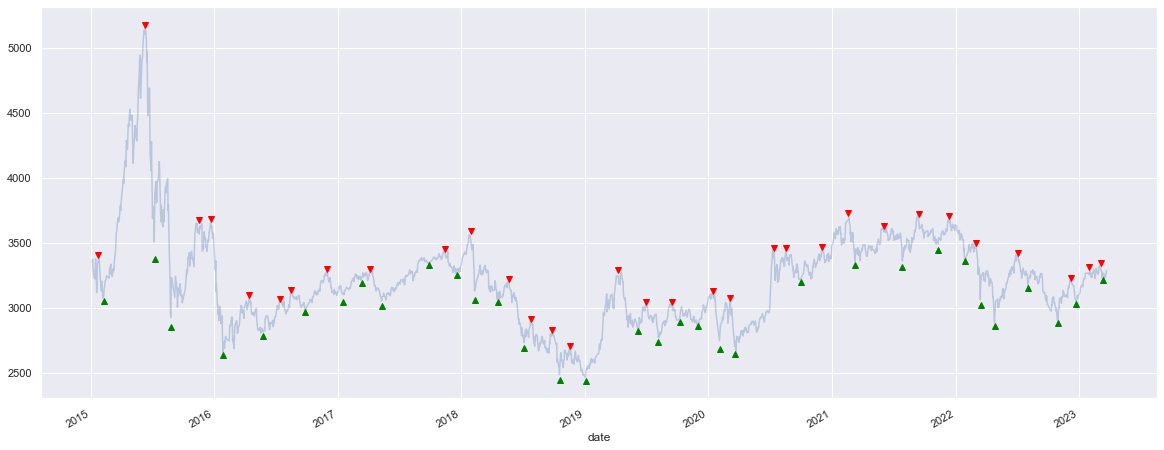

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
# This makes plots prettier
import seaborn; seaborn.set()
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from scipy.signal import argrelextrema
import numpy as np
pd.options.plotting.backend = "matplotlib"

sh300['date'] = sh300['date'].apply(pd.to_datetime)
x = sh300[sh300['date'].isin(pd.date_range(start='2015-01-01', end='2023-03-23'))]
x = x.set_index('date')

ilocs_min = argrelextrema(x.low.values, np.less_equal, order=20)[0]
ilocs_max = argrelextrema(x.high.values, np.greater_equal, order=20)[0]

x.close.plot(figsize=(20,8), alpha=.3)
# filter prices that are peaks and plot them differently to be visable on the plot
x.iloc[ilocs_max].high.plot(style='.', lw=10, color='red', marker="v");
x.iloc[ilocs_min].low.plot(style='.', lw=10, color='green', marker="^");

In [36]:
x.iloc[ilocs_min]

,open,close,high,low,volume,amount
date,,,,,,
2015-02-09,3063.51,3095.12,3119.03,3049.11,206108383,2.407197e+11
2015-07-09,3432.45,3709.33,3748.48,3373.54,656914611,6.733110e+11
2015-08-26,2980.79,2927.29,3092.04,2850.71,466699663,4.617890e+11
2016-01-27,2756.08,2735.56,2768.77,2638.30,215722045,2.074267e+11
2016-05-26,2813.54,2822.44,2827.09,2780.76,114766797,1.271052e+11
2016-09-27,2974.59,2998.17,2998.23,2969.13,121701450,1.333727e+11
2017-01-16,3104.49,3103.43,3105.14,3044.29,257885996,2.628260e+11
2017-03-13,3209.45,3237.02,3237.12,3193.16,163673761,2.069197e+11
2017-05-11,3036.79,3061.50,3063.56,3016.53,191341901,1.976041e+11


In [51]:
x.iloc[ilocs_max]

,open,close,high,low,volume,amount
date,,,,,,
2015-01-23,3357.10,3351.76,3406.79,3328.29,366249239,4.209795e+11
2015-06-12,5143.34,5166.35,5178.19,5103.40,625627855,1.060167e+12
2015-11-17,3629.98,3604.79,3678.27,3598.07,383575468,5.215204e+11
2015-12-23,3653.28,3636.09,3684.57,3633.02,298201802,4.199029e+11
2016-04-13,3041.36,3066.64,3097.17,3041.36,310003246,3.314207e+11
2016-07-13,3049.51,3060.69,3069.05,3048.20,253659384,2.793509e+11
2016-08-16,3130.53,3110.04,3140.44,3102.06,278328934,3.085449e+11
2016-11-29,3269.23,3282.92,3301.21,3263.40,320836288,3.481494e+11
2017-04-07,3280.62,3286.62,3295.19,3275.05,236108943,2.667383e+11


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
# This makes plots prettier
import seaborn; seaborn.set()
%matplotlib inline

from scipy.signal import argrelextrema
import numpy as np

sh001['date'] = sh001['date'].apply(pd.to_datetime)
x = sh001[sh001['date'].isin(pd.date_range(start='2021-01-01', end='2023-03-20'))]
x = x.set_index('date')

ilocs_min = argrelextrema(x.low.values, np.less_equal, order=20)[0]
ilocs_max = argrelextrema(x.high.values, np.greater_equal, order=10)[0]

x.close.plot(figsize=(20,8), alpha=.3)
# filter prices that are peaks and plot them differently to be visable on the plot
x.iloc[ilocs_max].high.plot(style='.', lw=10, color='red', marker="v");
x.iloc[ilocs_min].low.plot(style='.', lw=10, color='green', marker="^");

NameError: name 'sh001' is not defined

<AxesSubplot:xlabel='date'>

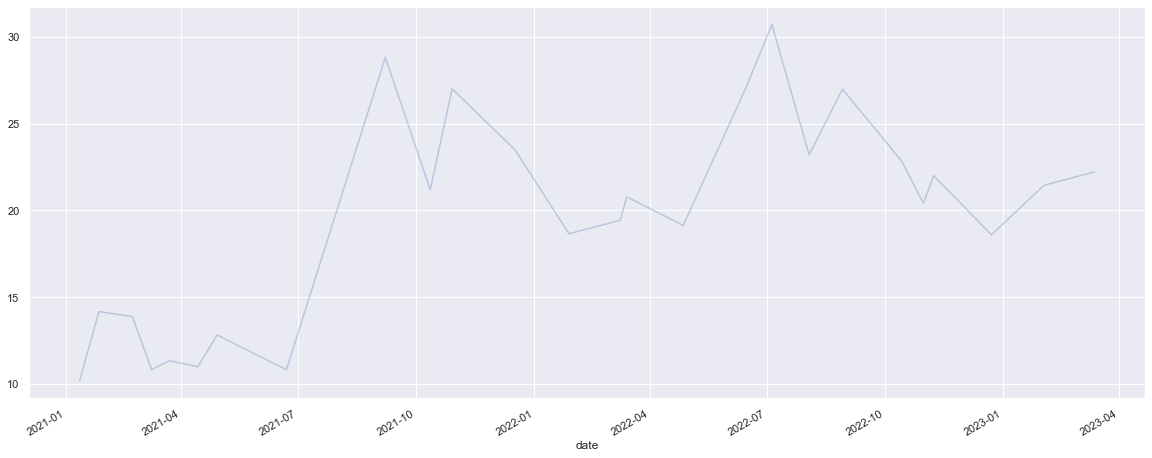

In [201]:
x.iloc[np.append(ilocs_min,ilocs_max)].close.plot(figsize=(20,8), alpha=.3)

<AxesSubplot:xlabel='date'>

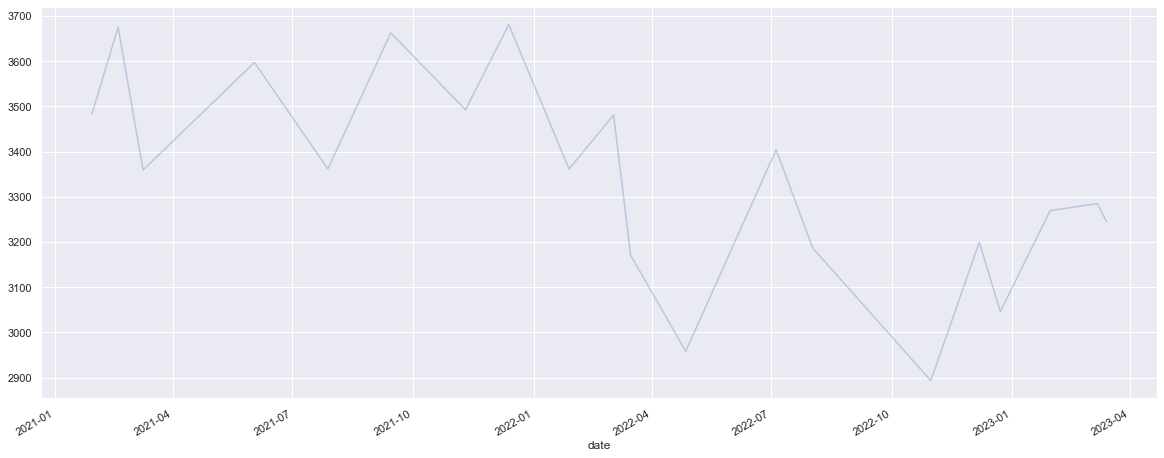

In [195]:
x.iloc[np.append(ilocs_min,ilocs_max)].close.plot(figsize=(20,8), alpha=.3)

In [196]:
x.iloc[ilocs_min]

,open,close,high,low,volume,amount
date,,,,,,
2021-01-29,3521.72,3483.07,3531.60,3446.55,293662664,4.165286e+11
2021-03-09,3415.34,3359.29,3429.15,3328.31,407652539,4.561962e+11
2021-07-28,3355.82,3361.59,3385.54,3312.72,395825418,5.646977e+11
2021-11-10,3498.94,3492.46,3498.94,3448.44,307030707,4.431127e+11
2022-01-28,3407.59,3361.44,3417.05,3356.56,290855258,3.537746e+11
2022-03-16,3107.67,3170.71,3177.79,3023.30,444667190,5.223053e+11
2022-04-27,2866.82,2958.28,2959.18,2863.65,423060191,4.229283e+11
2022-08-02,3231.26,3186.27,3231.26,3155.19,394176168,4.759627e+11
2022-10-31,2893.20,2893.48,2926.02,2885.09,301994203,3.966542e+11


In [202]:
x.iloc[ilocs_min]

,日期,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率,close,high,low
date,,,,,,,,,,,,,,
2021-01-12,2021-01-12,9.77,10.18,10.25,9.77,1205837,1.217781e+09,4.90,3.88,0.38,3.25,10.18,10.25,9.77
2021-03-09,2021-03-09,10.94,10.81,11.12,10.51,945866,1.026830e+09,5.57,-1.28,-0.14,2.55,10.81,11.12,10.51
2021-04-14,2021-04-14,10.71,10.98,11.10,10.70,437652,4.753916e+08,3.72,2.23,0.24,1.18,10.98,11.10,10.70
2021-06-22,2021-06-22,10.83,10.81,10.93,10.73,495728,5.373309e+08,1.84,-0.37,-0.04,1.33,10.81,10.93,10.73
2021-10-12,2021-10-12,22.10,21.19,22.18,20.71,1286208,2.739351e+09,6.68,-3.68,-0.81,3.40,21.19,22.18,20.71
2022-01-28,2022-01-28,19.02,18.65,19.17,17.93,626884,1.159025e+09,6.53,-1.74,-0.33,1.65,18.65,19.17,17.93
2022-03-09,2022-03-09,19.76,19.43,19.88,18.30,646928,1.242949e+09,8.08,-0.61,-0.12,1.71,19.43,19.88,18.30
2022-04-27,2022-04-27,17.80,19.13,19.19,17.53,817497,1.500896e+09,9.20,6.04,1.09,2.16,19.13,19.19,17.53
2022-08-03,2022-08-03,23.93,23.20,24.26,23.12,757562,1.793709e+09,4.83,-1.78,-0.42,2.00,23.20,24.26,23.12


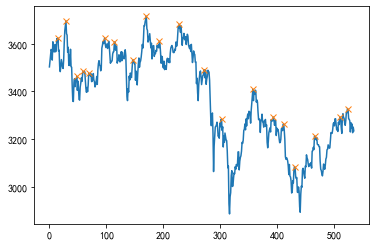

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


x = x.reset_index(drop=True)
peaks, _ = find_peaks(x, height=500,width=5)
plt.plot(x)
plt.plot(peaks, x[peaks], "x")
# plt.plot(np.zeros_like(x), "--", color="gray")
plt.show()